# 🗄️ Ejercicio Avanzado 3 — SQL desde cero con datos de planta
### Concentradora Apumarca (ficticia) · *60 días de operación simulados*

**¿Qué es SQL?** Es el lenguaje estándar para consultar bases de datos. **No necesitas cuenta ni servidor**: usamos **SQLite**, que viene incluido en Python y guarda toda la base en un archivo `.db`.

**Objetivo:** crear una base de datos desde Excel y aprender las consultas esenciales paso a paso:
`SELECT` → `WHERE` → `ORDER BY` → `GROUP BY` → `JOIN`

**Las 3 tablas:**
- `turnos` — producción por turno (tonelaje, ley, recuperación)
- `operadores` — quién operó cada turno
- `paradas` — paradas de equipos

In [1]:
import pandas as pd
import sqlite3

xls = "../data/07_planta_turnos_apumarca.xlsx"
turnos = pd.read_excel(xls, sheet_name="turnos")
operadores = pd.read_excel(xls, sheet_name="operadores")
paradas = pd.read_excel(xls, sheet_name="paradas")
turnos.head()

,registro_id,fecha,turno,operador_id,tonelaje_tms,ley_cabeza_au_g_t,recuperacion_pct
0,1,2026-05-01,Dia,3,1185,4.78,89.7
1,2,2026-05-01,Noche,5,1101,5.13,87.5
2,3,2026-05-02,Dia,3,1221,3.74,88.8
3,4,2026-05-02,Noche,5,1087,3.86,94.2
4,5,2026-05-03,Dia,5,1057,3.38,89.7


## 1. Crear la base de datos SQLite
`to_sql` convierte cada DataFrame en una tabla de la base `planta_apumarca.db`.

In [2]:
import tempfile, os
db_path = os.path.join(tempfile.gettempdir(), "planta_apumarca.db")  # archivo .db portable
con = sqlite3.connect(db_path)
turnos.to_sql("turnos", con, if_exists="replace", index=False)
operadores.to_sql("operadores", con, if_exists="replace", index=False)
paradas.to_sql("paradas", con, if_exists="replace", index=False)

def sql(consulta):
    """Ejecuta una consulta y devuelve un DataFrame."""
    return pd.read_sql_query(consulta, con)

sql("SELECT name FROM sqlite_master WHERE type='table'")

,name
0,turnos
1,operadores
2,paradas


## 2. `SELECT` — leer datos
Estructura básica: `SELECT columnas FROM tabla LIMIT n`

In [3]:
sql("SELECT fecha, turno, tonelaje_tms, ley_cabeza_au_g_t FROM turnos LIMIT 5")

,fecha,turno,tonelaje_tms,ley_cabeza_au_g_t
0,2026-05-01,Dia,1185,4.78
1,2026-05-01,Noche,1101,5.13
2,2026-05-02,Dia,1221,3.74
3,2026-05-02,Noche,1087,3.86
4,2026-05-03,Dia,1057,3.38


## 3. `WHERE` — filtrar filas
"Dame los turnos con recuperación menor a 87 %" (los turnos problema):

In [4]:
sql("""
SELECT fecha, turno, recuperacion_pct, ley_cabeza_au_g_t
FROM turnos
WHERE recuperacion_pct < 87
ORDER BY recuperacion_pct ASC
""")

,fecha,turno,recuperacion_pct,ley_cabeza_au_g_t
0,2026-06-24,Dia,83.5,3.37
1,2026-06-16,Dia,84.8,3.89
2,2026-05-18,Noche,84.9,4.36
3,2026-06-14,Dia,85.5,4.03
4,2026-05-26,Noche,85.7,4.85
5,2026-06-28,Noche,85.7,5.07
6,2026-06-06,Dia,85.8,4.50
7,2026-05-14,Dia,86.3,2.74
8,2026-06-29,Noche,86.3,3.99
9,2026-05-30,Noche,86.4,4.28


## 4. `GROUP BY` — resumir (el equivalente a las tablas dinámicas de Excel)
Producción y recuperación promedio **por turno** (día vs noche):

In [5]:
sql("""
SELECT turno,
       COUNT(*)                  AS n_turnos,
       SUM(tonelaje_tms)         AS tonelaje_total,
       ROUND(AVG(ley_cabeza_au_g_t), 2) AS ley_promedio,
       ROUND(AVG(recuperacion_pct), 1)  AS rec_promedio
FROM turnos
GROUP BY turno
""")

,turno,n_turnos,tonelaje_total,ley_promedio,rec_promedio
0,Dia,60,67734,4.41,89.2
1,Noche,60,68791,4.57,89.6


## 5. `JOIN` — combinar tablas (el "BUSCARV" de SQL)
La tabla `turnos` solo tiene `operador_id`. Con `JOIN` traemos el **nombre** desde la tabla `operadores` y rankeamos por recuperación:

In [6]:
sql("""
SELECT o.nombre, o.guardia,
       COUNT(*) AS turnos_operados,
       ROUND(AVG(t.recuperacion_pct), 2) AS rec_promedio
FROM turnos t
JOIN operadores o ON t.operador_id = o.operador_id
GROUP BY o.nombre, o.guardia
ORDER BY rec_promedio DESC
""")

,nombre,guardia,turnos_operados,rec_promedio
0,L. Condori,B,12,90.10
1,R. Quispe,A,15,89.67
2,S. Apaza,C,14,89.56
3,M. Huaman,A,22,89.55
4,A. Ccopa,C,22,89.15
5,J. Mamani,B,35,89.13


## 6. Consulta integradora: ¿las paradas afectan la producción?
Unimos `turnos` con `paradas` por fecha y comparamos el tonelaje de días con y sin paradas.

In [7]:
comparacion = sql("""
SELECT CASE WHEN p.fecha IS NULL THEN 'Sin paradas' ELSE 'Con paradas' END AS dia_tipo,
       COUNT(DISTINCT t.fecha)      AS dias,
       ROUND(AVG(t.tonelaje_tms),0) AS tonelaje_prom_turno
FROM turnos t
LEFT JOIN (SELECT DISTINCT fecha FROM paradas) p ON t.fecha = p.fecha
GROUP BY dia_tipo
""")
comparacion

,dia_tipo,dias,tonelaje_prom_turno
0,Con paradas,20,1150.0
1,Sin paradas,40,1132.0


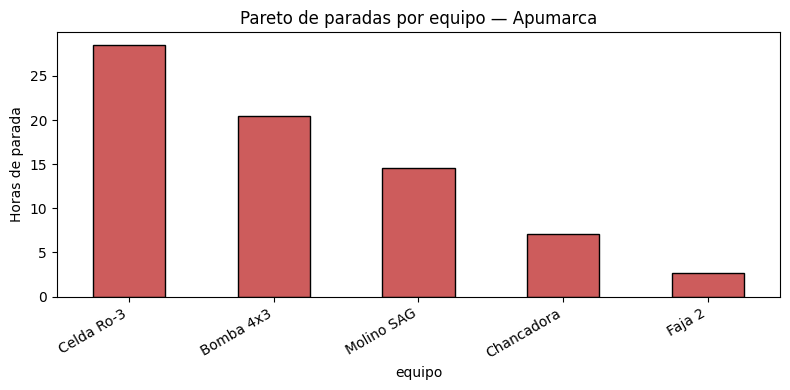

In [8]:
import matplotlib.pyplot as plt

horas = sql("""
SELECT equipo, ROUND(SUM(horas_parada),1) AS horas_totales
FROM paradas GROUP BY equipo ORDER BY horas_totales DESC
""")
horas.plot(kind="bar", x="equipo", y="horas_totales", legend=False,
           color="indianred", edgecolor="k", figsize=(8, 4))
plt.ylabel("Horas de parada"); plt.title("Pareto de paradas por equipo — Apumarca")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

con.close()

## ✅ Lo que aprendiste
| Comando | Para qué sirve | Equivalente en Excel |
|---|---|---|
| `SELECT` | elegir columnas | seleccionar columnas |
| `WHERE` | filtrar filas | filtros |
| `ORDER BY` | ordenar | ordenar |
| `GROUP BY` | resumir por categoría | tabla dinámica |
| `JOIN` | combinar tablas | BUSCARV / XLOOKUP |

> 🚀 Con estos 5 comandos resuelves ~80 % de las consultas del día a día. SQLite es idéntico en sintaxis básica a PostgreSQL/MySQL que usan las empresas mineras.